In [3]:
!pip install yfinance requests fredapi matplotlib pandas

In [4]:
from google.colab import userdata
import yfinance as yf
import requests
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Load API keys from Colab Secrets
NEWS_API_KEY = userdata.get('NEWS_API_KEY')
FRED_API_KEY = userdata.get('FRED_API_KEY')

In [5]:
def get_stock_data(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    df = stock.history(period="1mo")
    info = stock.info
    print(f"\nCompany: {info.get('longName', ticker)}")
    print(f"Current Price: ${info.get('currentPrice', 'N/A')}")
    print(f"52W High: ${info.get('fiftyTwoWeekHigh', 'N/A')}")
    print(f"52W Low: ${info.get('fiftyTwoWeekLow', 'N/A')}")
    return df

stock_df = get_stock_data("AAPL")
print(stock_df.tail())


Company: Apple Inc.
Current Price: $255.92
52W High: $288.62
52W Low: $169.21
                                 Open        High         Low       Close  \
Date                                                                        
2026-03-27 00:00:00-04:00  253.899994  255.490005  248.070007  248.800003   
2026-03-30 00:00:00-04:00  250.070007  250.869995  245.509995  246.630005   
2026-03-31 00:00:00-04:00  247.910004  255.479996  247.100006  253.789993   
2026-04-01 00:00:00-04:00  254.080002  256.179993  253.330002  255.630005   
2026-04-02 00:00:00-04:00  254.199997  256.130005  250.649994  255.919998   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-03-27 00:00:00-04:00  47900000        0.0           0.0  
2026-03-30 00:00:00-04:00  39446200        0.0           0.0  
2026-03-31 00:00:00-04:00  49598100        0.0           0.0  
2026-04-01 00:00:00-04:00  40059400        0.0           0.0  
202

In [6]:
def get_news(query="stock market"):
    url = f"https://newsapi.org/v2/everything?q={query}&sortBy=publishedAt&apiKey={NEWS_API_KEY}&pageSize=5"
    response = requests.get(url)
    data = response.json()

    if data["status"] != "ok":
        print("News API error:", data.get("message"))
        return

    print(f"\n📰 Latest News for: '{query}'\n" + "="*50)
    for i, article in enumerate(data["articles"], 1):
        print(f"\n{i}. {article['title']}")
        print(f"{article['url']}")
        print(f"{article['publishedAt'][:10]}")

get_news("stock market")


📰 Latest News for: 'stock market'

1. High-stakes timing: Trump’s Iran warning expires just after markets open on Monday - what can happen?
https://economictimes.indiatimes.com/news/international/us/high-stakes-timing-trumps-iran-warning-expires-just-after-markets-open-on-monday-what-can-happen/articleshow/130023967.cms
2026-04-04

2. Dollar Tree invests to improve customer shopping experience
https://www.thestreet.com/retail/dollar-tree-invests-to-improve-customer-shopping-experience
2026-04-04

3. Suits & Sayings: Tangled Ties
https://economictimes.indiatimes.com/magazines/panache/suits-sayings-tangled-ties/articleshow/130023686.cms
2026-04-04

4. Show HN: Trading harness for Indian stock market
https://github.com/hopit-ai/india-trade-cli
2026-04-04

5. Bottom-fishing stocks? Five things to watch out for
https://www.thehindubusinessline.com/portfolio/personal-finance/bottom-fishing-stocks-five-things-to-watch-out-for/article70819798.ece
2026-04-04


In [7]:
def get_economic_data():
    fred = Fred(api_key=FRED_API_KEY)

    gdp = fred.get_series('GDP')
    inflation = fred.get_series('CPIAUCSL')
    unemployment = fred.get_series('UNRATE')

    print("\n🏦 Economic Indicators")
    print("="*50)
    print(f"📈 Latest GDP:          ${gdp.iloc[-1]:,.2f} Billion")
    print(f"💸 Latest CPI:          {inflation.iloc[-1]:.2f}")
    print(f"👷 Unemployment Rate:   {unemployment.iloc[-1]}%")

    return gdp, inflation, unemployment

gdp, inflation, unemployment = get_economic_data()


🏦 Economic Indicators
📈 Latest GDP:          $31,442.48 Billion
💸 Latest CPI:          327.46
👷 Unemployment Rate:   4.3%


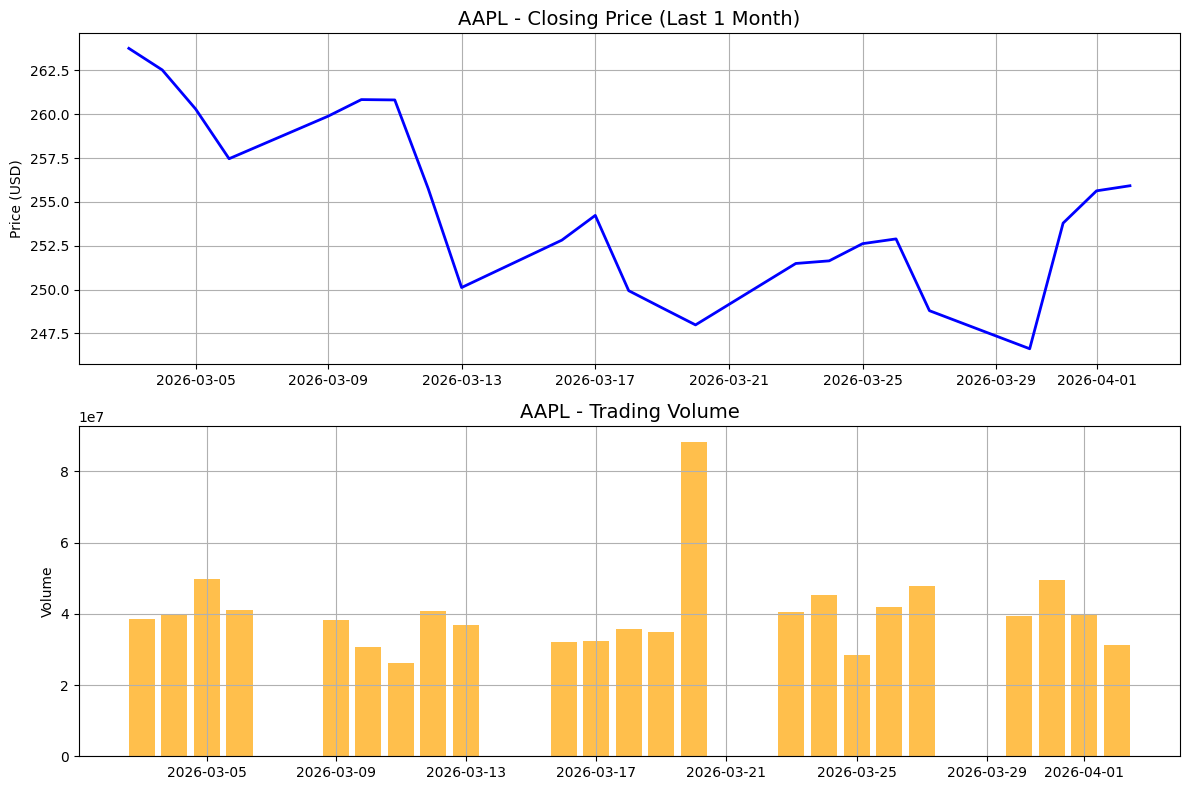

In [8]:
def plot_stock(df, ticker="AAPL"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Price chart
    axes[0].plot(df.index, df["Close"], color="blue", linewidth=2)
    axes[0].set_title(f"{ticker} - Closing Price (Last 1 Month)", fontsize=14)
    axes[0].set_ylabel("Price (USD)")
    axes[0].grid(True)

    # Volume chart
    axes[1].bar(df.index, df["Volume"], color="orange", alpha=0.7)
    axes[1].set_title(f"{ticker} - Trading Volume", fontsize=14)
    axes[1].set_ylabel("Volume")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_stock(stock_df, "AAPL")

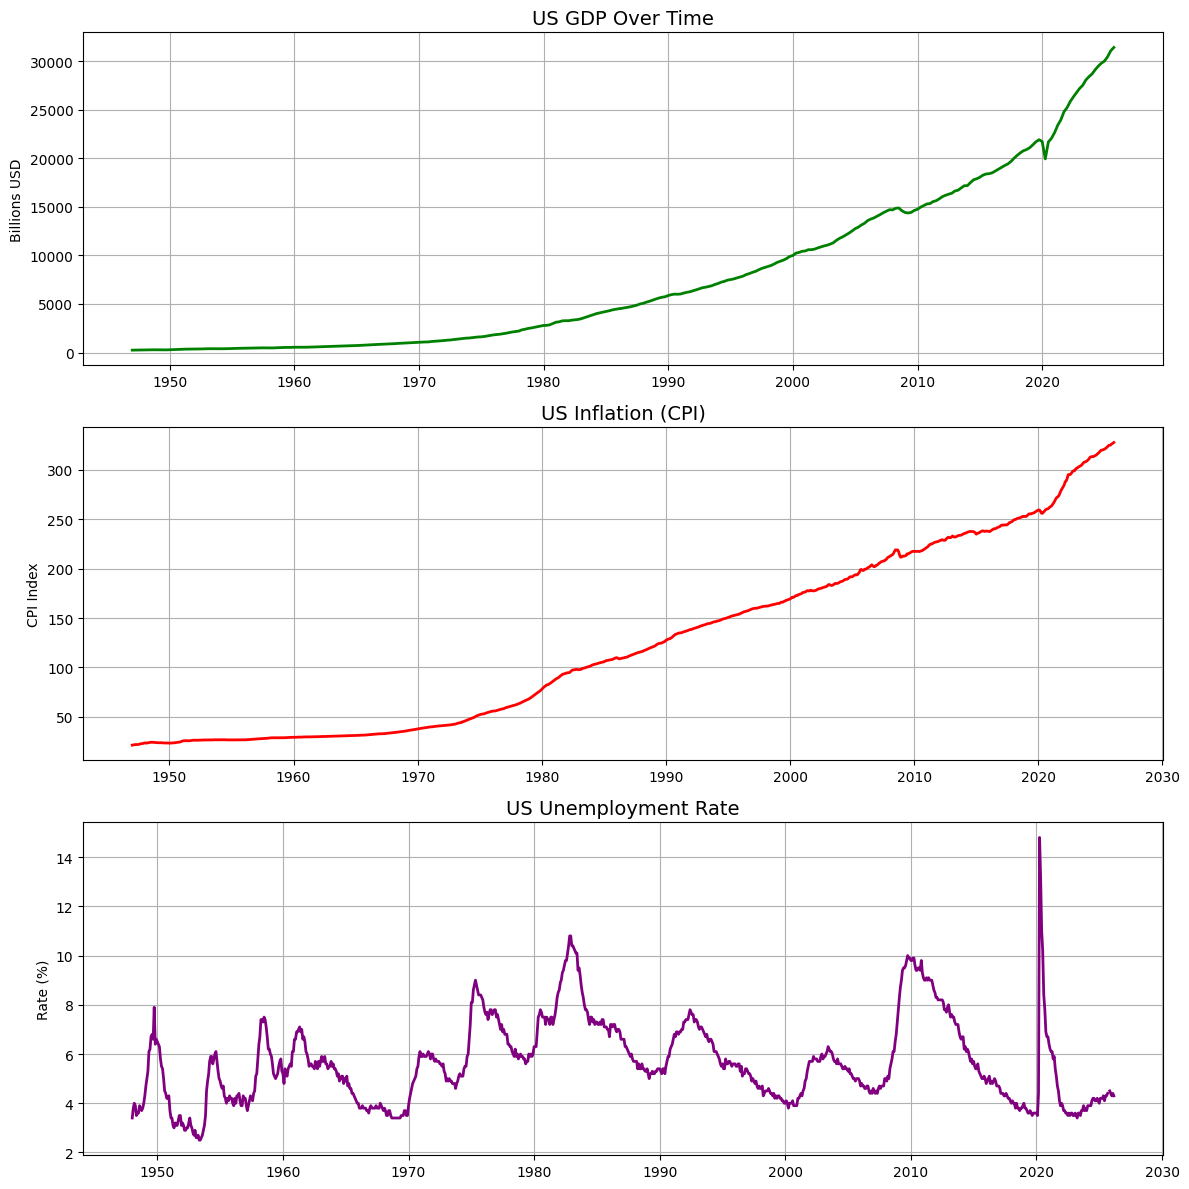

In [9]:
def plot_economic(gdp, inflation, unemployment):
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    axes[0].plot(gdp.index, gdp.values, color="green", linewidth=2)
    axes[0].set_title("US GDP Over Time", fontsize=14)
    axes[0].set_ylabel("Billions USD")
    axes[0].grid(True)

    axes[1].plot(inflation.index, inflation.values, color="red", linewidth=2)
    axes[1].set_title("US Inflation (CPI)", fontsize=14)
    axes[1].set_ylabel("CPI Index")
    axes[1].grid(True)

    axes[2].plot(unemployment.index, unemployment.values, color="purple", linewidth=2)
    axes[2].set_title("US Unemployment Rate", fontsize=14)
    axes[2].set_ylabel("Rate (%)")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_economic(gdp, inflation, unemployment)

In [10]:
def run_dashboard(ticker="TSLA", news_query="stock market"):
    print("="*60)
    print(f"FINANCIAL DASHBOARD — {ticker}")
    print("="*60)

    # Stock
    stock_df = get_stock_data(ticker)
    plot_stock(stock_df, ticker)

    # News
    get_news(news_query)

    # Economy
    gdp, inflation, unemployment = get_economic_data()
    plot_economic(gdp, inflation, unemployment)

    print("\nDashboard Complete!")

Enter stock ticker (e.g. AAPL, TSLA, INFY):AAPL
Enter news topic:Apple stock
FINANCIAL DASHBOARD — AAPL

Company: Apple Inc.
Current Price: $255.92
52W High: $288.62
52W Low: $169.21


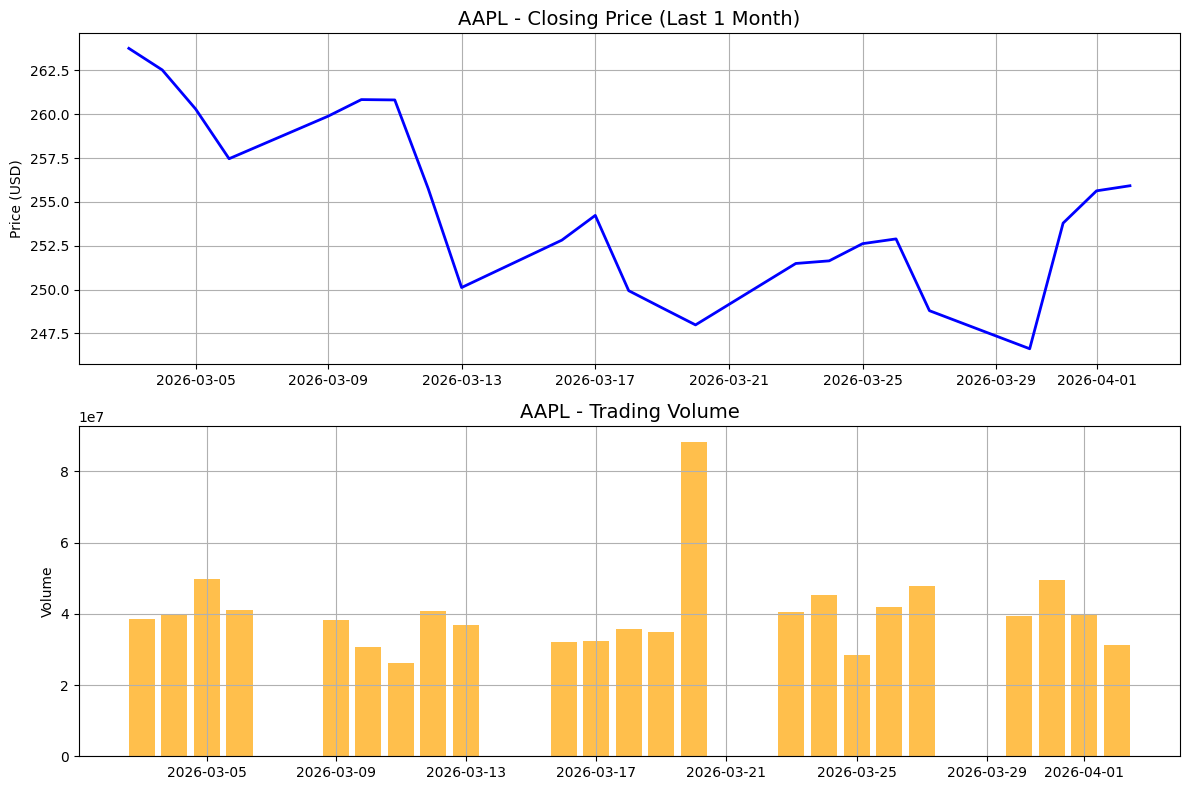


📰 Latest News for: 'Apple stock'

1. 7 Reasons These Camera-Free Smart Glasses Keep Winning
https://the-gadgeteer.com/2026/04/04/7-reasons-these-camera-free-smart-glasses-keep-winning/
2026-04-04

2. VIPOutlet Deals at eBay: Up to 73% off + extra 10% off + free shipping
https://www.dealnews.com/VIPOutlet-Deals-at-eBay-Up-to-73-off-extra-10-off-free-shipping/21820263.html
2026-04-04

3. Target Closed, Walmart Open on Easter 2026: Costco and Many Retailers Shut for Holiday
https://www.ibtimes.com.au/target-closed-walmart-open-easter-2026-costco-many-retailers-shut-holiday-1865389
2026-04-04

4. Forget Face ID: Why Apple’s Foldable is Bringing Back the Fingerprint Sensor - Geeky Gadgets
https://slashdot.org/firehose.pl?op=view&amp;id=181220858
2026-04-04

5. Buffett may end donations to Gates charity over Bill's ties to Epstein
https://www.cnbc.com/2026/04/04/buffett-may-end-donations-to-gates-charity-over-bills-ties-to-epstein.html
2026-04-04

🏦 Economic Indicators
📈 Latest GDP:        

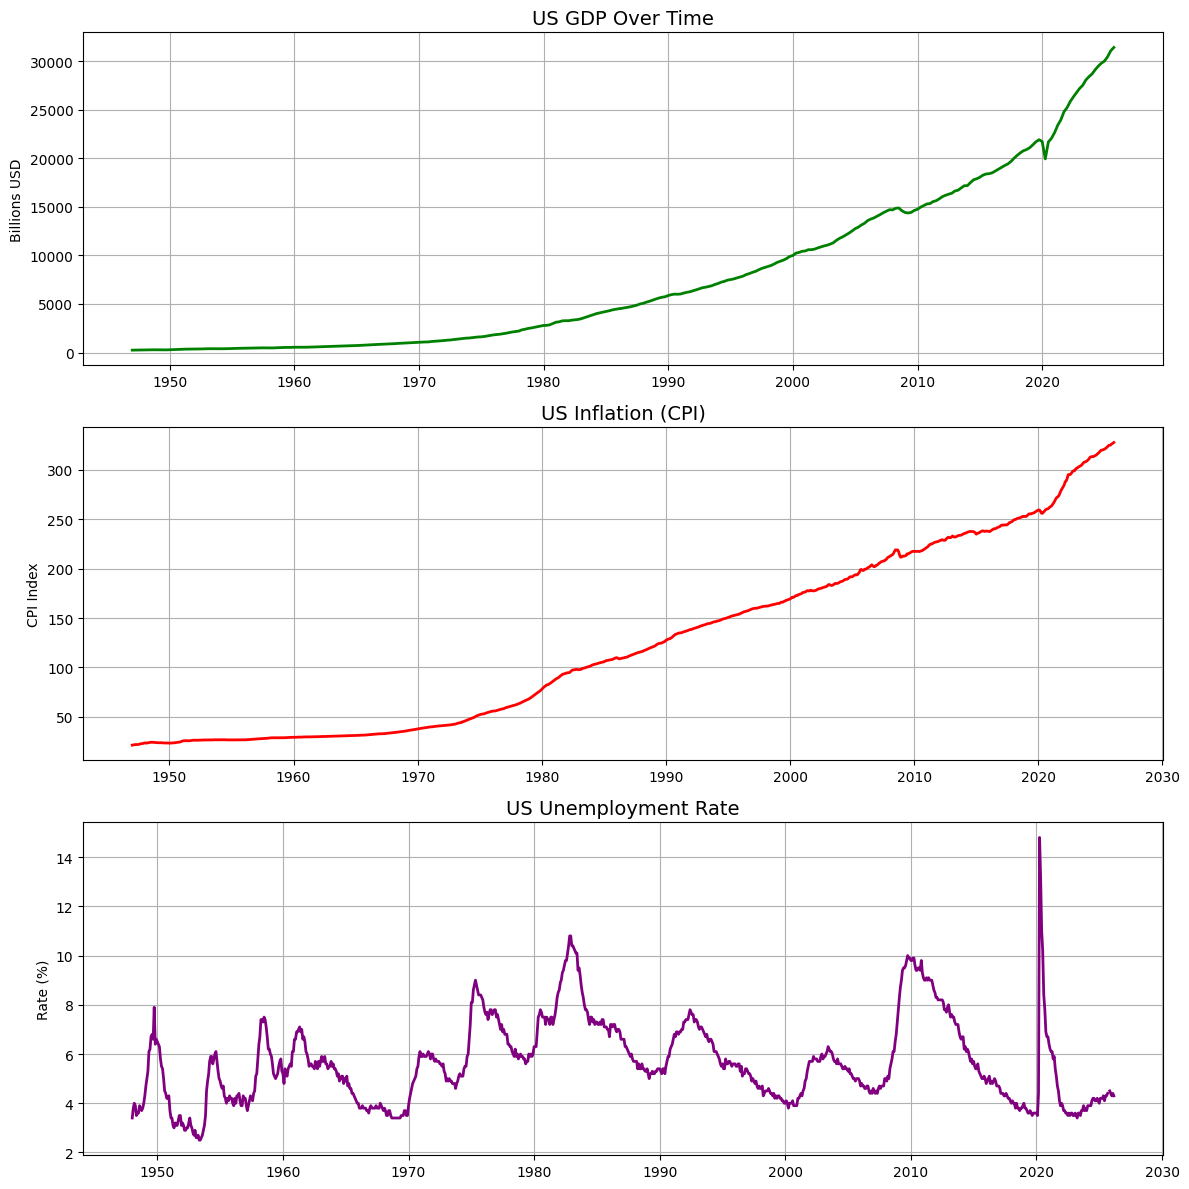


Dashboard Complete!


In [11]:
ticker = input("Enter stock ticker (e.g. AAPL, TSLA, INFY):")
news_query = input("Enter news topic:")
run_dashboard(ticker=ticker, news_query=news_query)

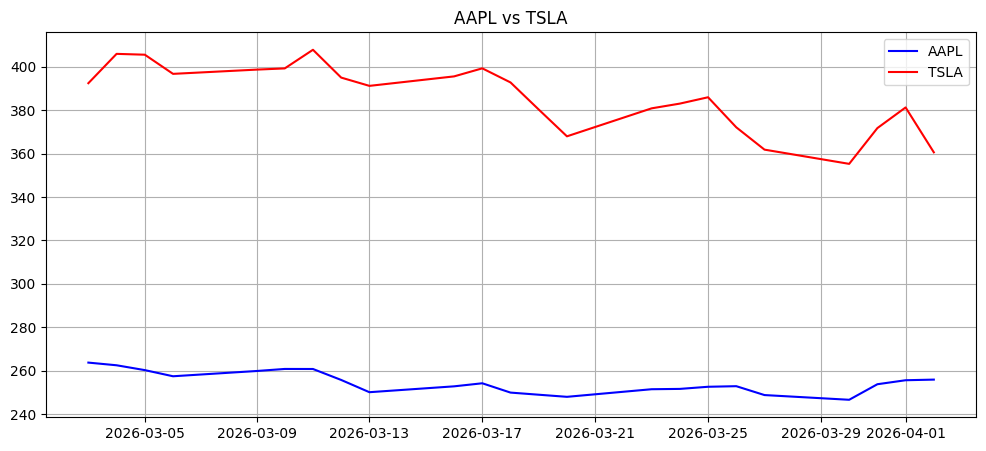

In [12]:
import yfinance as yf
import matplotlib.pyplot as plt

def compare_stocks(ticker1="AAPL", ticker2="TSLA"):
    df1 = yf.Ticker(ticker1).history(period="1mo")["Close"]
    df2 = yf.Ticker(ticker2).history(period="1mo")["Close"]

    plt.figure(figsize=(12,5))
    plt.plot(df1.index, df1.values, label=ticker1, color="blue")
    plt.plot(df2.index, df2.values, label=ticker2, color="red")
    plt.title(f"{ticker1} vs {ticker2}")
    plt.legend()
    plt.grid(True)
    plt.show()

compare_stocks("AAPL", "TSLA")

Download the data directly to your device.

In [13]:
import matplotlib.backends.backend_pdf as pdf_backend
import yfinance as yf
import matplotlib.pyplot as plt

def save_dashboard_pdf(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    df = stock.history(period="1mo")

    with pdf_backend.PdfPages(f"{ticker}_report.pdf") as pdf:
        fig, ax = plt.subplots(figsize=(12,5))
        ax.plot(df["Close"], color="blue")
        ax.set_title(f"{ticker} - Stock Report")
        ax.grid(True)
        pdf.savefig(fig)
        plt.close()
    print(f"Report saved as {ticker}_report.pdf")

save_dashboard_pdf("AAPL")

# Download the PDF to your laptop
from google.colab import files
files.download("AAPL_report.pdf")

Report saved as AAPL_report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The below will display the moving average chart.

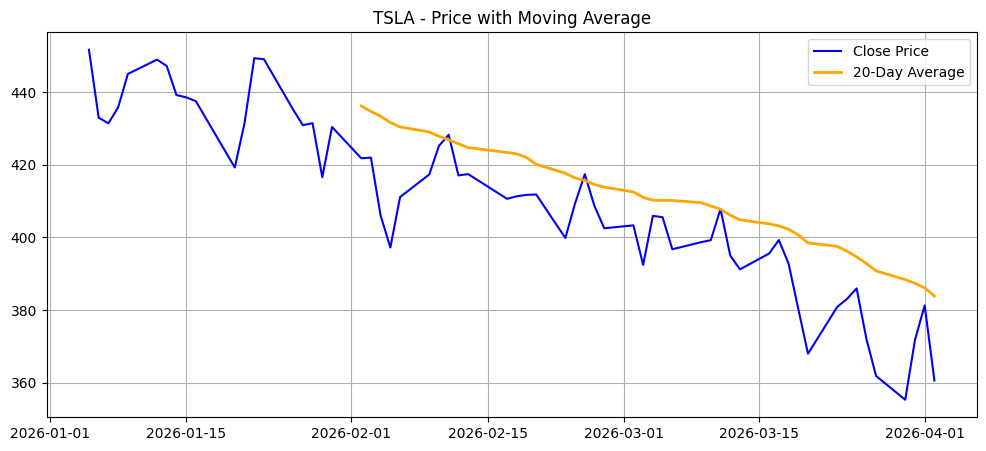

In [14]:
import yfinance as yf
import matplotlib.pyplot as plt

def plot_with_moving_average(ticker="TSLA"):
    stock = yf.Ticker(ticker)
    df = stock.history(period="3mo")

    df["MA20"] = df["Close"].rolling(window=20).mean()

    plt.figure(figsize=(12,5))
    plt.plot(df["Close"], label="Close Price", color="blue")
    plt.plot(df["MA20"], label="20-Day Average", color="orange", linewidth=2)
    plt.title(f"{ticker} - Price with Moving Average")
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the function
plot_with_moving_average("TSLA")

This will give you the candle stick chart.
🟢 Green Candle = Good Day
Price went UP that day
Open price was LOWER
Close price was HIGHER

🔴 Red Candle = Bad Day
Price went DOWN that day
Open price was HIGHER
Close price was LOWER


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.2 MB/s eta 0:00:00


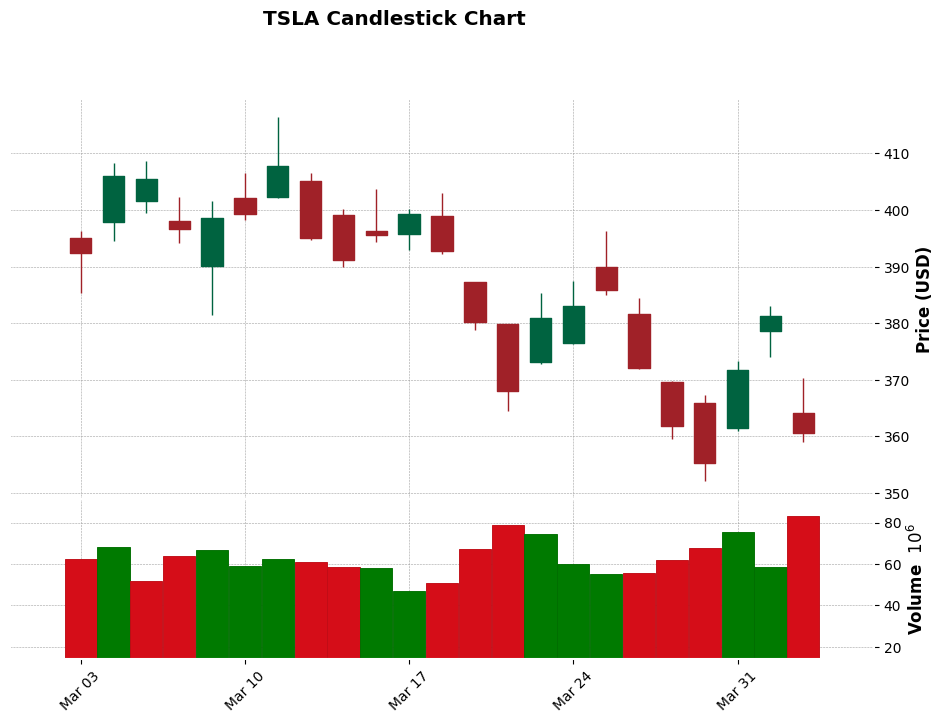

In [15]:
!pip install mplfinance

import mplfinance as mpf

def candlestick_chart(ticker="TSLA"):
    stock = yf.Ticker(ticker)
    df = stock.history(period="1mo")

    mpf.plot(df,
             type="candle",
             style="charles",
             title=f"{ticker} Candlestick Chart",
             ylabel="Price (USD)",
             volume=True,
             figsize=(12,8))

candlestick_chart("TSLA")